In [33]:
import numpy as np
import astropy.units as u
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from importlib import reload
from astropy.io import fits
import copy

from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle
import matplotlib.pyplot as plt

from scoobscc.math_module import xp, xcipy, ensure_np_array
from scoobscc import utils
from scoobscc import dm
from scoobscc import scc_sim as scc
import scoobscc.scoob_model as scoobm

wfe_data = utils.load_pickle('/home/derbyk/src/scoob-scc/data_sim/example_wfe_data.pkl')

Oversampling > 2x suggested for reliable results in Fresnel propagation.


Text(0.5, 1.0, 'Modulated Coro Image')

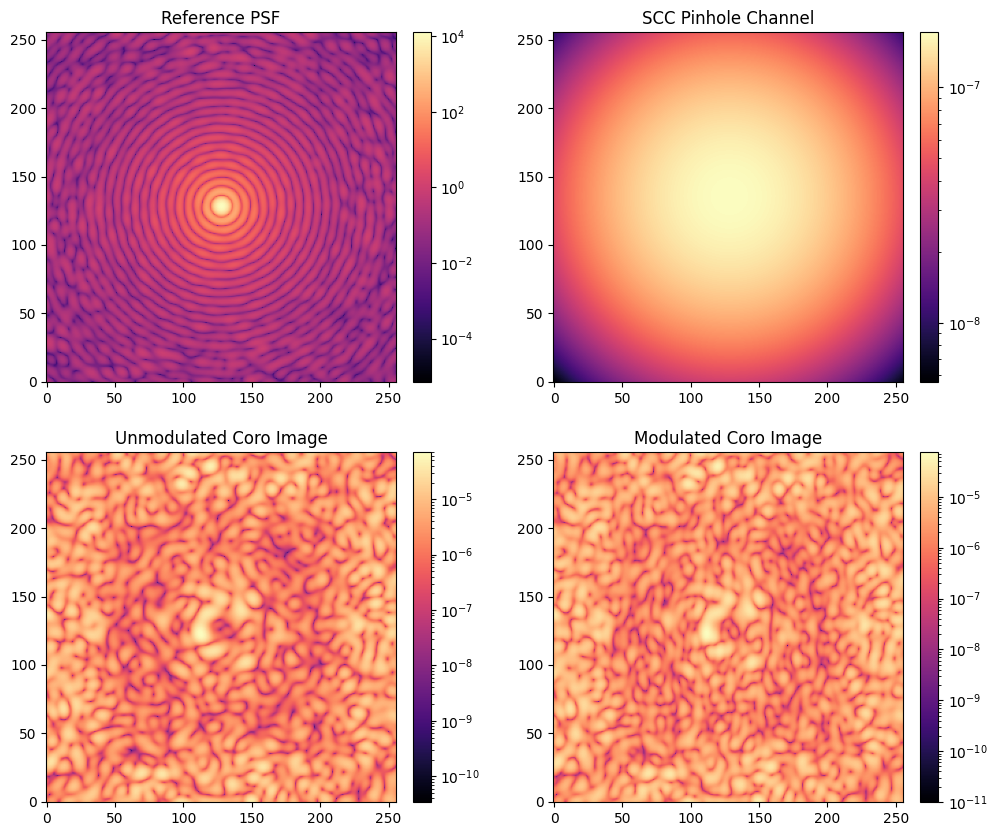

In [91]:
reload(scoobm)
reload(utils)

M = scoobm.single()
M.ncamsci = 256

M.PREFPM_AMP = wfe_data['PREFPM_AMP']
M.PREFPM_OPD = wfe_data['PREFPM_OPD']

M.POSTFPM_AMP = wfe_data['POSTFPM_AMP']
M.POSTFPM_OPD = wfe_data['POSTFPM_OPD']

M.RLS_AMP = wfe_data['RLS_AMP']
M.RLS_OPD = wfe_data['RLS_OPD']

M.dm_ref = wfe_data['DM_FLAT']
M.reset_dm()

iwa = 3
owa = 10
# control_mask = utils.create_annular_focal_plane_mask(
control_mask = utils.create_annular_mask(
    M.ncamsci, 
    M.camsci_pxscl_lamD, 
    iwa, 
    owa,  
    edge=iwa,)
# imshow1(control_mask, pxscl=M.camsci_pxscl_lamD)

M.LYOT = M.LYOTSTOP
M.use_vortex = 0
ref_psf = M.snap_camsci()
M.Imax_ref = xp.max(ref_psf)

M.use_vortex = 1
im_unmod = M.snap_camsci()
mean_contrast_unmod = xp.mean(im_unmod[control_mask])

M.LYOT = M.PINHOLE
ref_scc = M.snap_camsci()
# ref_scc = xp.ones((256, 256))

M.LYOT = M.SCCSTOP
im_mod = M.snap_camsci()
mean_contrast_mod = xp.mean(im_mod[control_mask])

plt.figure(figsize=(12, 10))
plt.subplot(221)
plt.imshow(ref_psf.get(), cmap='magma', norm='log',)
plt.colorbar(fraction=0.046, pad=0.04)
plt.title('Reference PSF')
plt.subplot(222)
plt.imshow(ref_scc.get(), cmap='magma', norm='log',)
plt.colorbar(fraction=0.046, pad=0.04)
plt.title('SCC Pinhole Channel')
plt.subplot(223)
plt.imshow(im_unmod.get(), cmap='magma', norm='log',)
plt.colorbar(fraction=0.046, pad=0.04)
plt.title('Unmodulated Coro Image')
plt.subplot(224)
plt.imshow(im_mod.get(), cmap='magma', norm='log',)
plt.colorbar(fraction=0.046, pad=0.04)
plt.title('Modulated Coro Image')

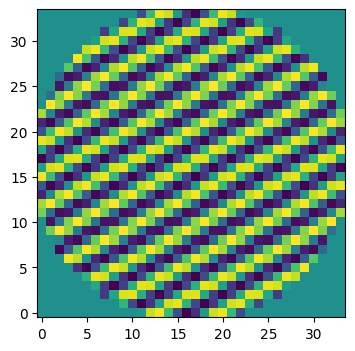

In [96]:
hmodes = dm.create_hadamard_modes(M.dm_mask)
fmodes = dm.create_fourier_modes(dm_mask=M.dm_mask, npsf=im_mod.shape[0], psf_pixelscale_lamD=M.camsci_pxscl_lamD * 2, 
                                 iwa=iwa, owa=owa, fourier_sampling=0.75, which='both')

plt.figure(figsize=(5, 4))
plt.imshow(fmodes[10].get())

In [107]:
M.reset_dm()

ims_mod, ims_unmod = scc.grab_image_cubes(I=M, control_mask=control_mask, calibration_amplitude=5e-9, calibration_modes=hmodes)

Calibrating Jacobian...


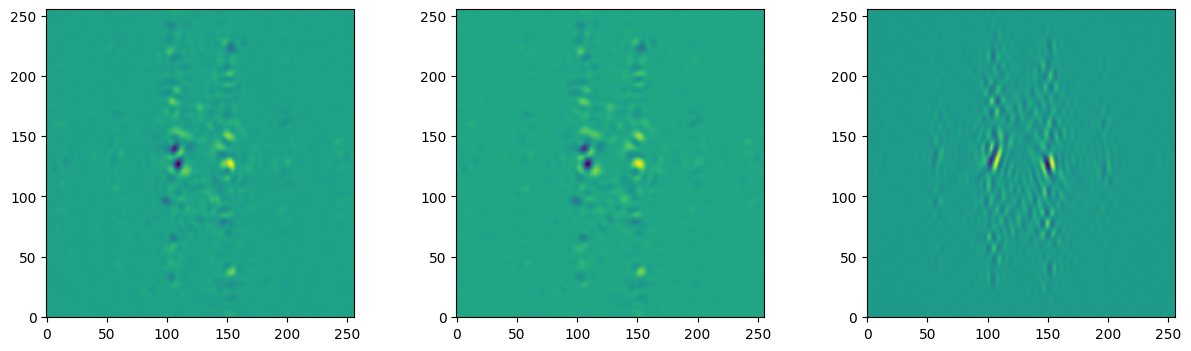

In [108]:
ind = 100
diff1 = ims_mod[:, :, ind, 0] - ims_mod[:, :, ind, 1]
diff2 = ims_unmod[:, :, ind, 0] - ims_unmod[:, :, ind, 1]
ddiff = diff1 - diff2 

plt.figure(figsize=(15, 4))
plt.subplot(131)
plt.imshow(diff1.get())
plt.subplot(132)
plt.imshow(diff2.get())
plt.subplot(133)
plt.imshow(ddiff.get())

In [109]:
Nmask = int(control_mask.sum())
Nmodes = hmodes.shape[0]
Ncamsci = im_mod.shape[0]
calibration_amplitude = 5e-9

calib_amps = np.array([-calibration_amplitude, calibration_amplitude])

jacobian = xp.zeros((Nmask, Nmodes))
jacobian_full = xp.zeros((Ncamsci ** 2, Nmodes))

for i in range(Nmodes):

    diff1 = ims_mod[:, :, i, 0] - ims_mod[:, :, i, 1]
    diff2 = ims_unmod[:, :, i, 0] - ims_unmod[:, :, i, 1]
    ddiff = diff1 - diff2 

    response = ddiff / (2 * calibration_amplitude)

    jacobian[:, i] = response[control_mask].ravel()
    jacobian_full[:, i] = response.ravel()

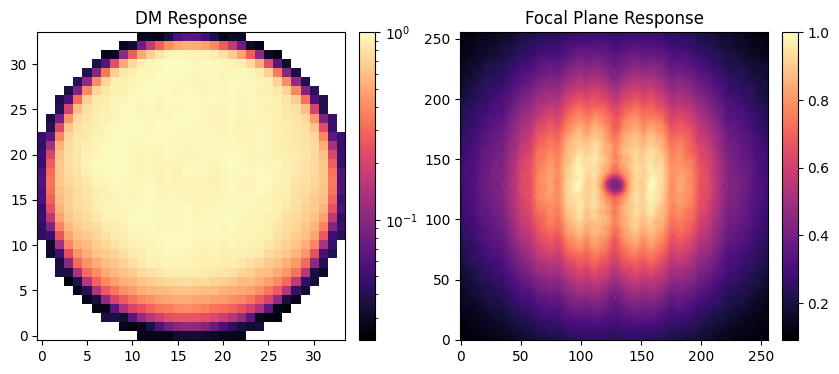

In [110]:
dm_modes = utils.ensure_np_array(hmodes)

dm_response_map = np.sqrt(np.mean(np.abs(utils.ensure_np_array(jacobian).dot(dm_modes.reshape(dm_modes.shape[0], -2))), axis=0))
dm_response_map = dm_response_map.reshape(34, 34) / np.max(dm_response_map)

fp_response_map = np.sqrt(np.mean(np.abs(utils.ensure_np_array(jacobian_full)), axis=1)).reshape(256, 256)
fp_response_map /= np.max(fp_response_map)

plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.title('DM Response')
plt.imshow(dm_response_map, cmap='magma', norm='log')
plt.colorbar(fraction=0.046, pad=0.04)
plt.subplot(122)
plt.title('Focal Plane Response')
plt.imshow(fp_response_map, cmap='magma')
plt.colorbar(fraction=0.046, pad=0.04)

In [111]:
cmTI = utils.TikhonovInverse(jacobian, rcond=1e-2)
cm20 = utils.beta_reg(jacobian, -2)
cm25 = utils.beta_reg(jacobian, -2.5)
cm30 = utils.beta_reg(jacobian, -3)
cm35 = utils.beta_reg(jacobian, -3.5)
cm40 = utils.beta_reg(jacobian, -4)
cm45 = utils.beta_reg(jacobian, -4.5)
cm50 = utils.beta_reg(jacobian, -5)

In [112]:
M.reset_dm()
data = {
    'images'       : [im_unmod],
    'commands'     : [xp.zeros((M.Nact,M.Nact))],
    'pixelscale'   : M.camsci_pxscl_lamD,
    'control_mask' : control_mask, 
}

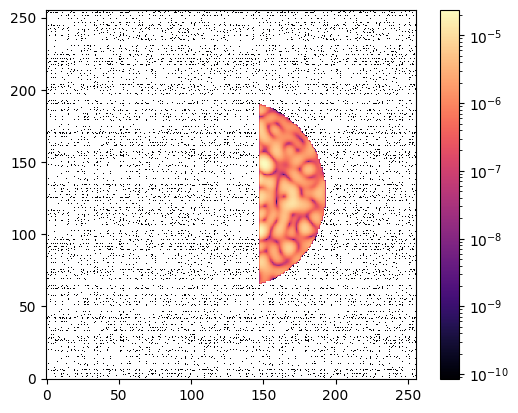

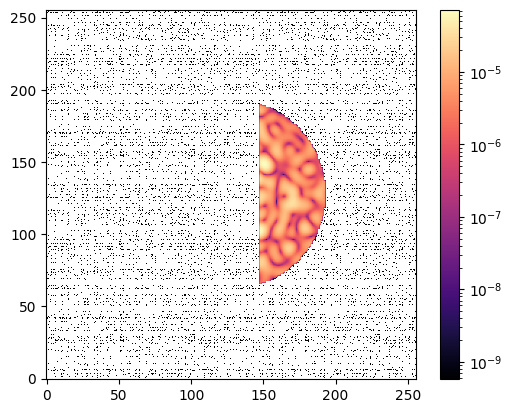

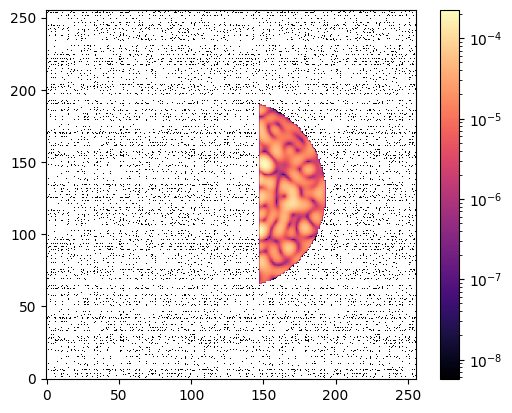

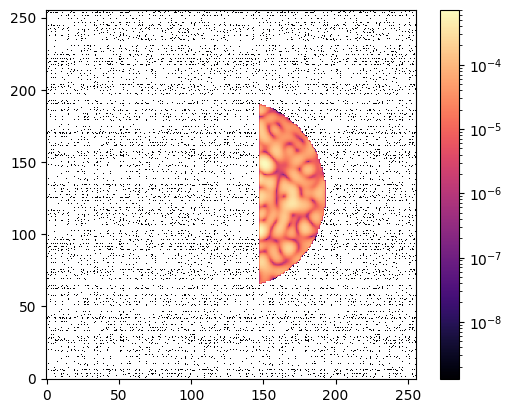

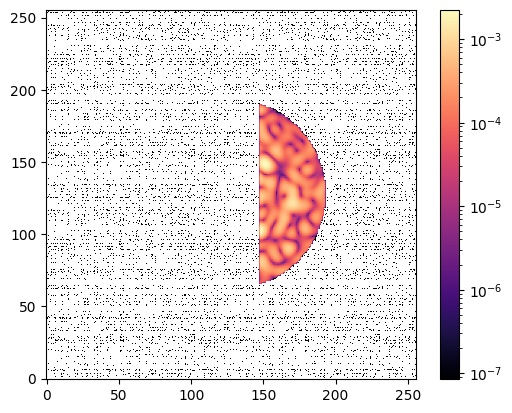

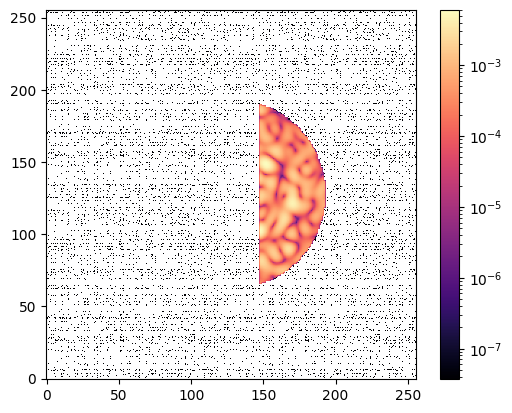

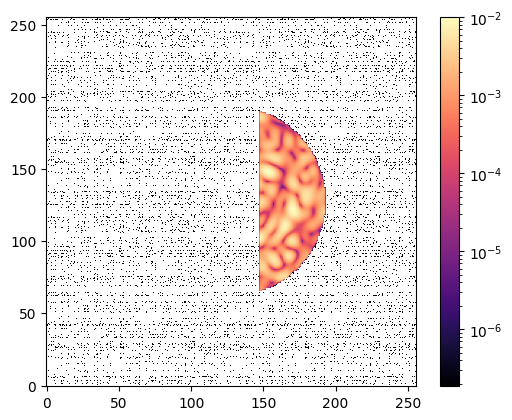

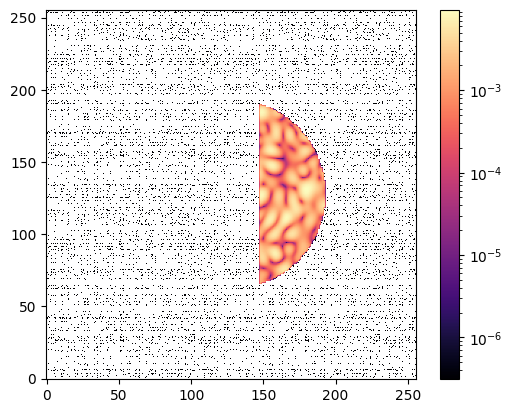

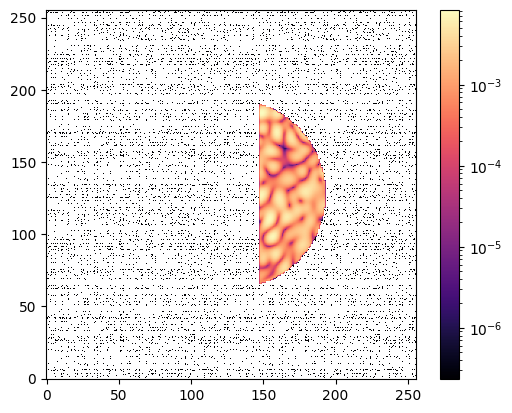

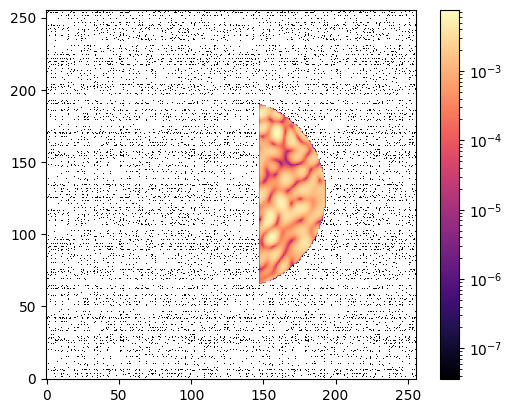

In [113]:
iterations = 10
gain = 0.75
leakage = 0.0
modes = hmodes

control_matrix = cmTI

Nmodes = modes.shape[0]
Nmask = int(control_mask.sum())
ctrl_modes = modes.reshape(Nmodes, -1)

command = copy.copy(data['commands'][-1])

for i in range(iterations):

    M.set_dm(command, channel=3)

    M.LYOT = M.SCCSTOP

    im_mod = M.snap_camsci()

    M.LYOT = M.LYOTSTOP

    im_unmod = M.snap_camsci()

    meas_vector = (im_mod - im_unmod - ref_scc)[control_mask].ravel()

    del_modes = control_matrix.dot(meas_vector)

    del_command = gain * del_modes.dot(ctrl_modes).reshape(M.Nact, M.Nact)
    
    command = (1.0 - leakage) * command - del_command

    data['images'].append(copy.copy(im_unmod))
    data['commands'].append(copy.copy(command))

    plt.figure()
    plt.imshow(utils.ensure_np_array(data['images'][-1] * control_mask), norm='log', cmap='magma')
    plt.colorbar()
    plt.show()